# 17 — State space (`math`, SciPy, PyTorch, python-control)

The plant from notebook `14` as a realization

$$
\\dot{x} = Ax + Bu,\\qquad y = Cx + Du
$$

python-control `tf2ss` is the spec. We check controllability / observability, compare Euler vs `lsim` vs `forced_response`, then on the GPU integrate **many initial conditions** as a single `(B, n)` state — a GEMM-shaped update.

In [1]:
from __future__ import annotations

import math
import time

import control as ct
import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy import signal

%matplotlib inline

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"python-control {ct.__version__}   torch {torch.__version__}   device {device}")
if device.type == "cuda":
    print(f"CUDA {torch.version.cuda}  |  {torch.cuda.get_device_name(0)}")


python-control 0.10.2   torch 2.14.0+cu132   device cuda
CUDA 13.2  |  NVIDIA GeForce RTX 3060


In [2]:
def bode_mag_phase(sys, omega):
    frd = ct.frequency_response(sys, omega=omega)
    if hasattr(frd, "magnitude"):
        w = np.asarray(frd.frequency).reshape(-1)
        m = np.asarray(frd.magnitude).reshape(-1)
        p = np.asarray(frd.phase).reshape(-1)
    else:
        mag, phase, om = frd
        w = np.asarray(om).reshape(-1)
        m = np.asarray(mag).reshape(-1)
        p = np.asarray(phase).reshape(-1)
    return w, m, p


def plot_bode(sys, title, marks=()):
    w, m, p = bode_mag_phase(sys, np.logspace(0, 5, 500))
    fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
    axes[0].semilogx(w / (2 * np.pi), 20 * np.log10(np.maximum(m, 1e-16)))
    axes[1].semilogx(w / (2 * np.pi), np.degrees(np.unwrap(p)))
    for f, lab in marks:
        axes[0].axvline(f, color="k", ls="--", lw=1, label=lab)
        axes[1].axvline(f, color="k", ls="--", lw=1)
    axes[0].set_ylabel("mag (dB)")
    axes[1].set_ylabel("phase (deg)")
    axes[1].set_xlabel("frequency (Hz)")
    for ax in axes:
        ax.grid(True, which="both", alpha=0.3)
    if marks:
        axes[0].legend()
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()
    return w, m, p


def max_abs(a, b) -> float:
    return float(np.max(np.abs(np.asarray(a, dtype=np.float64) - np.asarray(b, dtype=np.float64))))


In [3]:
FS_HZ = 8_192
DURATION_S = 0.80
FN_HZ = 8.0
ZETA = 0.20
N = int(FS_HZ * DURATION_S)
DT = 1.0 / FS_HZ
WN = 2.0 * math.pi * FN_HZ

t = np.arange(N, dtype=np.float64) / FS_HZ
u = np.ones(N, dtype=np.float64)
print(f"fn={FN_HZ} Hz  ζ={ZETA}  n={N}  device={device}")

fn=8.0 Hz  ζ=0.2  n=6553  device=cuda


## python-control — `tf2ss`, ranks, forced response

In [4]:
G = ct.tf([WN**2], [1.0, 2.0 * ZETA * WN, WN**2])
sys = ct.tf2ss(G)
A, B, C, D = np.asarray(sys.A), np.asarray(sys.B), np.asarray(sys.C), np.asarray(sys.D)
print("A\n", A)
print("B\n", B.T, "\nC", C, "\nD", D)
ctrb = ct.ctrb(A, B)
obsv = ct.obsv(A, C)
print(f"rank ctrb={np.linalg.matrix_rank(ctrb)}  rank obsv={np.linalg.matrix_rank(obsv)}  n={A.shape[0]}")
assert np.linalg.matrix_rank(ctrb) == A.shape[0]
assert np.linalg.matrix_rank(obsv) == A.shape[0]
_, y_ct = ct.forced_response(sys, T=t, U=u)
print("forced_response final", y_ct[-1])

A
 [[-2.01061930e+01 -2.52661873e+03]
 [ 1.00000000e+00  0.00000000e+00]]
B
 [[1. 0.]] 
C [[   0.         2526.61872668]] 
D [[0.]]
rank ctrb=2  rank obsv=2  n=2
forced_response final 0.9999734123586741


## `math` — forward Euler of \(\dot{x}=Ax+Bu\)

In [5]:
def math_ss(u_list, dt, A, B, C, D, x0=None):
    n = A.shape[0]
    x = [0.0] * n if x0 is None else [float(v) for v in x0]
    out = []
    for un in u_list:
        dx = [0.0] * n
        for i in range(n):
            s = 0.0
            for j in range(n):
                s += A[i, j] * x[j]
            s += B[i, 0] * un
            dx[i] = s
        x = [x[i] + dt * dx[i] for i in range(n)]
        y = D[0, 0] * un + sum(C[0, i] * x[i] for i in range(n))
        out.append(y)
    return out


y_math = math_ss(u.tolist(), DT, A, B, C, D)
print("math vs control", max_abs(y_ct, y_math))

math vs control 0.006643134293717434


## SciPy — `StateSpace` + `lsim` (variable-step), plus `cont2discrete` Euler

In [6]:
_tout, y_sp, _x = signal.lsim(signal.StateSpace(A, B, C, D), U=u, T=t)
y_sp = np.asarray(y_sp).reshape(-1)
Ad, Bd, Cd, Dd, _ = signal.cont2discrete((A, B, C, D), dt=DT, method="euler")
x = np.zeros((A.shape[0], 1))
y_d = np.empty(N)
for k, un in enumerate(u):
    y_d[k] = float(np.asarray(Cd @ x + Dd * un).reshape(-1)[0])
    x = Ad @ x + Bd * un
print(f"lsim vs control {max_abs(y_ct, y_sp):.3e}")
print(f"c2d-euler vs math {max_abs(y_math, y_d):.3e}")

lsim vs control 7.772e-16
c2d-euler vs math 4.660e-03


## PyTorch — batched initial conditions

\(x \\leftarrow x + \\Delta t\\,(x A^\\top + u B^\\top)\) for a batch of ICs. The plant matrices stay on `cuda`; the batch is 48 phase-space points.

In [7]:
def torch_ss_batch(u_t, dt, A_t, B_t, C_t, D_t, x0):
    # u_t: (T,), x0: (B, n), A_t: (n, n)
    Bsz, n = x0.shape
    T = u_t.numel()
    x = x0.clone()
    y = torch.empty(Bsz, T, device=u_t.device, dtype=u_t.dtype)
    for i in range(T):
        un = u_t[i]
        dx = x @ A_t.T + un * B_t.T  # (B, n)
        x = x + dt * dx
        y[:, i] = (x @ C_t.reshape(n)) + (D_t.reshape(()) * un)
    return y, x


A_t = torch.as_tensor(A, device=device, dtype=torch.float32)
B_t = torch.as_tensor(B, device=device, dtype=torch.float32)
C_t = torch.as_tensor(C, device=device, dtype=torch.float32)
D_t = torch.as_tensor(D, device=device, dtype=torch.float32)
u_th = torch.as_tensor(u, device=device, dtype=torch.float32)
gen = torch.Generator(device="cpu")
gen.manual_seed(0)
x0 = (0.4 * torch.randn(48, A.shape[0], generator=gen)).to(device=device, dtype=torch.float32)
x0[0].zero_()
if device.type == "cuda":
    torch.cuda.synchronize()
t0 = time.perf_counter()
y_b, _xf = torch_ss_batch(u_th, DT, A_t, B_t, C_t, D_t, x0)
if device.type == "cuda":
    torch.cuda.synchronize()
print(f"ss batch {tuple(y_b.shape)} on {y_b.device} in {(time.perf_counter()-t0)*1e3:.1f} ms")
y_gpu = y_b[0].detach().cpu().numpy()
print("zero-IC vs math", max_abs(y_math, y_gpu))

ss batch (48, 6553) on cuda:0 in 879.5 ms
zero-IC vs math 9.450780713571305e-07


## Overlay + IC family

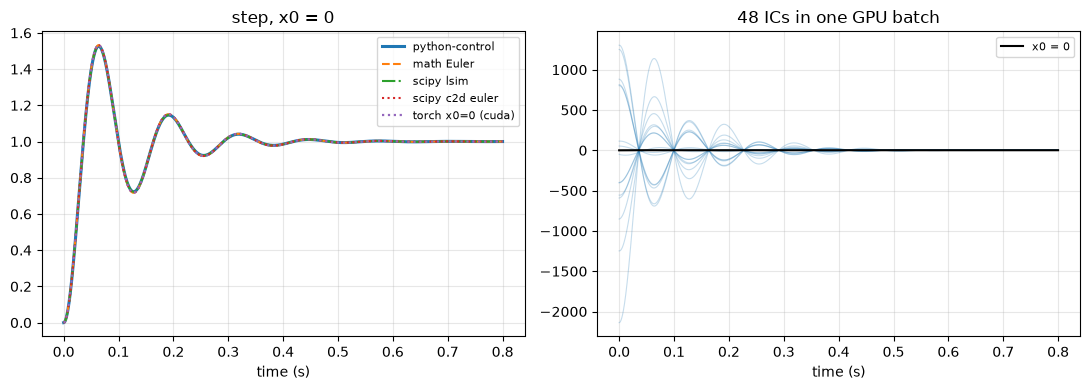

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(t, y_ct, lw=2.2, label="python-control")
axes[0].plot(t, y_math, ls="--", label="math Euler")
axes[0].plot(t, y_sp, ls="-.", label="scipy lsim")
axes[0].plot(t, y_d, ls=":", label="scipy c2d euler")
axes[0].plot(t, y_gpu, ls=":", lw=1.6, label=f"torch x0=0 ({device})")
axes[0].set_xlabel("time (s)")
axes[0].set_title("step, x0 = 0")
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=8)

ys = y_b.detach().cpu().numpy()
for row in ys[::3]:
    axes[1].plot(t, row, color="C0", alpha=0.25, lw=0.8)
axes[1].plot(t, ys[0], color="k", lw=1.5, label="x0 = 0")
axes[1].set_xlabel("time (s)")
axes[1].set_title(f"48 ICs in one GPU batch")
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

## Optional: pole placement (one set of gains, still GPU-batched ICs)

\(u = r - Kx\) with `control.place` putting both poles at \(-2\\zeta\\omega_n \\pm j\\omega_n\\sqrt{1-\\zeta_\\mathrm{cl}^2}\).

K [[6.03185789e+01 2.00088834e-11]] desired poles [-40.21238597+30.15928947j -40.21238597-30.15928947j]


closed-loop batch device cuda:0 final 1.0000025033950806


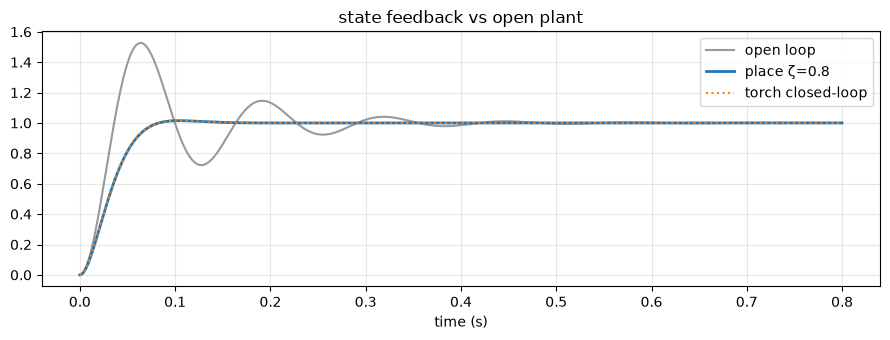

In [9]:
wn_cl = WN
zeta_cl = 0.8
p_des = np.roots([1.0, 2.0 * zeta_cl * wn_cl, wn_cl**2])
K = ct.place(A, B, p_des)
print("K", K, "desired poles", p_des)
A_cl = A - B @ K
sys_cl = ct.ss(A_cl, B, C, D)
_, y_cl = ct.forced_response(sys_cl, T=t, U=u)
A_cl_t = torch.as_tensor(A_cl, device=device, dtype=torch.float32)
y_cl_b, _ = torch_ss_batch(u_th, DT, A_cl_t, B_t, C_t, D_t, x0[:8])
print("closed-loop batch device", y_cl_b.device, "final", float(y_cl_b[0, -1]))

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(t, y_ct, color="0.6", label="open loop")
ax.plot(t, y_cl, lw=2.0, label="place ζ=0.8")
ax.plot(t, y_cl_b[0].detach().cpu().numpy(), ls=":", label="torch closed-loop")
ax.set_xlabel("time (s)")
ax.set_title("state feedback vs open plant")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

## Takeaways

- Controllable + observable is the license to place poles and to build observers later (`20+`).
- Euler `x + Δt(Ax+Bu)` matches `cont2discrete(..., method='euler')`; `lsim` / `forced_response` are the finer integrators.
- On a GPU the natural batch is **many \(x_0\)** (or many \((A,B)\) plants), not a longer single trajectory.
- Next (`18`): discretize \(A,B\) properly (ZOH / Tustin), not just forward Euler.